In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("spam.csv")

In [2]:
df.head()


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(415)

In [5]:
df = df.drop_duplicates(keep="first")

print(df['Category'].value_counts())

Category
ham     4516
spam     641
Name: count, dtype: int64


In [6]:
df['Message'] = df['Message'].str.lower()

In [7]:
df.head()


,Category,Message
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


In [8]:
import re 

df['Message'] = df['Message'].apply(lambda x: re.sub(r'[^\w\s]','',x))

In [9]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\me\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\me\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\me\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\me\AppData\Roaming\nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\me\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [10]:
from nltk.tokenize import word_tokenize

df['tokenize'] = df['Message'].apply(word_tokenize)

print(df[['Message','tokenize']].head())

                                             Message  \
0  go until jurong point crazy available only in ...   
1                            ok lar joking wif u oni   
2  free entry in 2 a wkly comp to win fa cup fina...   
3        u dun say so early hor u c already then say   
4  nah i dont think he goes to usf he lives aroun...   

                                            tokenize  
0  [go, until, jurong, point, crazy, available, o...  
1                     [ok, lar, joking, wif, u, oni]  
2  [free, entry, in, 2, a, wkly, comp, to, win, f...  
3  [u, dun, say, so, early, hor, u, c, already, t...  
4  [nah, i, dont, think, he, goes, to, usf, he, l...  


In [11]:
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['tokenize'] =df['tokenize'].apply(lambda x:[word for word in x if  word not in stop_words])

print(df['tokenize'].head())

0    [go, jurong, point, crazy, available, bugis, n...
1                       [ok, lar, joking, wif, u, oni]
2    [free, entry, 2, wkly, comp, win, fa, cup, fin...
3        [u, dun, say, early, hor, u, c, already, say]
4    [nah, dont, think, goes, usf, lives, around, t...
Name: tokenize, dtype: object


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\me\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_words(words):
    tagged = nltk.pos_tag(words)
    return [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged]

df['tokenize'] = df['tokenize'].apply(lemmatize_words)

df.head()


,Category,Message,tokenize
0,ham,go until jurong point crazy available only in ...,"[go, jurong, point, crazy, available, bugis, n..."
1,ham,ok lar joking wif u oni,"[ok, lar, joking, wif, u, oni]"
2,spam,free entry in 2 a wkly comp to win fa cup fina...,"[free, entry, 2, wkly, comp, win, fa, cup, fin..."
3,ham,u dun say so early hor u c already then say,"[u, dun, say, early, hor, u, c, already, say]"
4,ham,nah i dont think he goes to usf he lives aroun...,"[nah, dont, think, go, usf, life, around, though]"


In [13]:
df['proc_message'] = df['tokenize'].apply(lambda x: " ".join(x))
df[['tokenize','proc_message']].head()

,tokenize,proc_message
0,"[go, jurong, point, crazy, available, bugis, n...",go jurong point crazy available bugis n great ...
1,"[ok, lar, joking, wif, u, oni]",ok lar joking wif u oni
2,"[free, entry, 2, wkly, comp, win, fa, cup, fin...",free entry 2 wkly comp win fa cup final tkts 2...
3,"[u, dun, say, early, hor, u, c, already, say]",u dun say early hor u c already say
4,"[nah, dont, think, go, usf, life, around, though]",nah dont think go usf life around though


In [14]:
df.to_csv('cleaned_spam.csv', index=False)
print("Cleaned data saved as 'cleaned_spam.csv'")

Cleaned data saved as 'cleaned_spam.csv'


In [15]:
cs= pd.read_csv('cleaned_spam.csv')

In [16]:
cs.head()

,Category,Message,tokenize,proc_message
0,ham,go until jurong point crazy available only in ...,"['go', 'jurong', 'point', 'crazy', 'available'...",go jurong point crazy available bugis n great ...
1,ham,ok lar joking wif u oni,"['ok', 'lar', 'joking', 'wif', 'u', 'oni']",ok lar joking wif u oni
2,spam,free entry in 2 a wkly comp to win fa cup fina...,"['free', 'entry', '2', 'wkly', 'comp', 'win', ...",free entry 2 wkly comp win fa cup final tkts 2...
3,ham,u dun say so early hor u c already then say,"['u', 'dun', 'say', 'early', 'hor', 'u', 'c', ...",u dun say early hor u c already say
4,ham,nah i dont think he goes to usf he lives aroun...,"['nah', 'dont', 'think', 'go', 'usf', 'life', ...",nah dont think go usf life around though


In [17]:
cs['proc_message'] = cs['proc_message'].fillna('')
cs.head()

,Category,Message,tokenize,proc_message
0,ham,go until jurong point crazy available only in ...,"['go', 'jurong', 'point', 'crazy', 'available'...",go jurong point crazy available bugis n great ...
1,ham,ok lar joking wif u oni,"['ok', 'lar', 'joking', 'wif', 'u', 'oni']",ok lar joking wif u oni
2,spam,free entry in 2 a wkly comp to win fa cup fina...,"['free', 'entry', '2', 'wkly', 'comp', 'win', ...",free entry 2 wkly comp win fa cup final tkts 2...
3,ham,u dun say so early hor u c already then say,"['u', 'dun', 'say', 'early', 'hor', 'u', 'c', ...",u dun say early hor u c already say
4,ham,nah i dont think he goes to usf he lives aroun...,"['nah', 'dont', 'think', 'go', 'usf', 'life', ...",nah dont think go usf life around though


In [18]:
from sklearn.feature_extraction.text import CountVectorizer

In [19]:
cv = CountVectorizer()

count_num = cv.fit_transform(cs['proc_message'])

print('Matrix Shape')
print(count_num.shape)

print(cv.get_feature_names_out()[:20])

Matrix Shape
(5157, 8478)
['008704050406' '0089my' '0121' '01223585236' '01223585334' '0125698789'
 '02' '020603' '0207' '02070836089' '02072069400' '02073162414'
 '02085076972' '020903' '021' '050703' '0578' '06' '060505' '061104']


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [21]:
w_text = TfidfVectorizer(max_features=3000)

tfid = w_text.fit_transform(cs['proc_message'])
print("TF-IDF Matrix Shape:")
print(tfid.shape)

# Display a sample of the first 20 unique words the vectorizer chose for the vocabulary
print("\nFirst 20 TF-IDF Vocabulary Words:")
print(w_text.get_feature_names_out()[:20])

TF-IDF Matrix Shape:
(5157, 3000)

First 20 TF-IDF Vocabulary Words:
['008704050406' '020603' '07xxxxxxxxx' '0800' '08000839402' '08000930705'
 '08001950382' '0845' '0870' '08701417012' '08707509020' '08708034412'
 '08709222922' '08712300220' '08712317606' '08712402050' '08712405020'
 '08712405022' '08712460324' '08715705022']


In [22]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(cs['Category'])

In [23]:
import numpy as np
import scipy.sparse 

np.save('y_encoded.npy', y)

scipy.sparse.save_npz('X_features.npz', tfid)

print("Success! Features and labels saved for the modeling stage.")

Success! Features and labels saved for the modeling stage.


In [24]:
import numpy as np
import scipy.sparse

X_path = 'X_features.npz'
y_path = 'y_encoded.npy'

y = np.load(y_path)
X = scipy.sparse.load_npz(X_path)


print(f"Features shape: {X.shape}")
print(f"Category shape: {y.shape}")

Features shape: (5157, 3000)
Category shape: (5157,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Training Data Shape ---")
print(X_train.shape)
print("\n--- Testing Data Shape ---")
print(X_test.shape)

--- Training Data Shape ---
(4125, 3000)

--- Testing Data Shape ---
(1032, 3000)


In [26]:
!pip install xgboost

from xgboost import XGBClassifier

model = XGBClassifier(scale_pos_weight= 2,random_state=42, eval_metric='logloss')

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [27]:
y_pred = model.predict(X_test)

print("--- Predict 10 model ---")
print(y_pred[:10])

--- Predict 10 model ---
[0 0 0 0 0 1 1 0 1 0]


In [28]:
import numpy as np
import joblib

joblib.dump(model, 'xgboost_spam_model.pkl')

np.save('y_test.npy', y_test)
np.save('y_pred.npy', y_pred)

print("Success! Model and predictions saved for the final evaluation.")

Success! Model and predictions saved for the final evaluation.


In [29]:
y_test = np.load('y_test.npy')
y_pred = np.load('y_pred.npy')

model = joblib.load( 'xgboost_spam_model.pkl')

print("Data and model loaded successfully! Ready to evaluate performance.")

Data and model loaded successfully! Ready to evaluate performance.


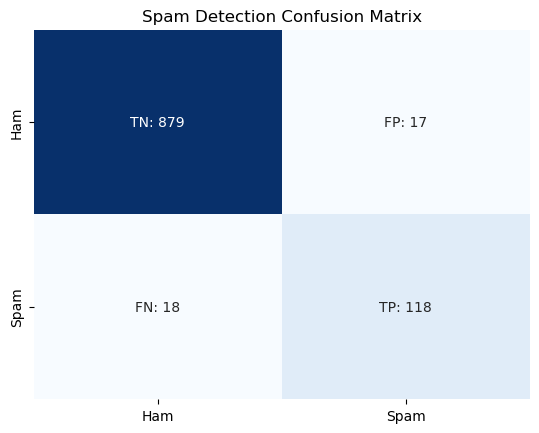

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
labels = [[f"TN: {cm[0,0]}", f"FP: {cm[0,1]}"], [f"FN: {cm[1,0]}", f"TP: {cm[1,1]}"]]

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], cbar=False)
plt.title('Spam Detection Confusion Matrix')
plt.show()

In [31]:
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score

print("Accuracy: ",round(accuracy_score(y_test, y_pred),2))
print("Precision:", round(precision_score(y_test, y_pred),2))
print("Recall:   ", round(recall_score(y_test, y_pred),2))
print("F1 Score: ", round(f1_score(y_test, y_pred),2))

Accuracy:  0.97
Precision: 0.87
Recall:    0.87
F1 Score:  0.87


In [32]:
import joblib

joblib.dump(model,'SpamModel.pk1')
joblib.dump(w_text, "vectorizer.pkl")

['vectorizer.pkl']